# Q-factorisation on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy
from sklearn.decomposition import PCA

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from networks import FactorisedDQN_QNetwork
from environments.fourrooms_discrete import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def get_base_env(env):
    return env.unwrapped

def collect_valid_states_fourrooms(env):

    base_env = get_base_env(env)

    if not hasattr(base_env, "_free_cells"):
        raise RuntimeError("Base env does not expose _free_cells.")

    coords = np.asarray(base_env._free_cells, dtype=np.int32)      # [N, 2]
    states = coords.astype(np.float32)                             # obs == (x, y)

    return states, coords

def shared_pca_projection(emb_before, emb_after, n_components=2):
    X = np.concatenate([emb_before, emb_after], axis=0)
    pca = PCA(n_components=n_components)
    Xp = pca.fit_transform(X)
    Z_before = Xp[:emb_before.shape[0]]
    Z_after = Xp[emb_before.shape[0]:]
    return Z_before, Z_after, pca

def plot_before_after(Z_before, Z_after, label_before, label_after, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(Z_before[:, 0], Z_before[:, 1], s=25, alpha=0.7, label=label_before)
    plt.scatter(Z_after[:, 0], Z_after[:, 1], s=25, alpha=0.7, label=label_after)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [3]:
def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env


In [4]:
BUFFER_CAPACITY = 100000
GOAL = (9, 9)
LR = float(1e-3)

env = make_env(goal=GOAL)
obs_dim = env.observation_space.shape[0]
num_actions = env.action_space.n
task_embedding_memory = []


# Factorised Q-network instead of plain DQN_QNetwork
# Goal is 2-D (grid coordinates), so goal_dim=2
q_net = FactorisedDQN_QNetwork(
    obs_dim=obs_dim,
    num_actions=num_actions,
    goal_dim=2,
    hidden_dim=128,
    rep_dim=64,
).to(DEVICE)

q_target = FactorisedDQN_QNetwork(
    obs_dim=obs_dim,
    num_actions=num_actions,
    goal_dim=2,
    hidden_dim=128,
    rep_dim=64,
).to(DEVICE)

q_target.load_state_dict(q_net.state_dict())
for p in q_target.parameters():
    p.requires_grad_(False)


def dqn_train(
    seed: int = 42,
    q_network=q_net,
    q_target_network=q_target,
    env=env,
    buffer_capacity=BUFFER_CAPACITY,
    lr=LR,
    obs_dim=obs_dim,
    device=DEVICE,
    total_steps=100000,
    warmup_steps=5000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=50000,
    train_freq=4,
    goal=GOAL,
    params=None,
    regulariser=None,
    reg_alpha=500,
    embedding_memory=task_embedding_memory
):
    set_seed(seed)

    if params is None:
        opt = optim.Adam([
            {"params": q_network.sa_encoder.parameters(), "lr": lr},
            {"params": q_network.goal_encoder.parameters(), "lr": lr},
        ])
    else:
        opt = optim.Adam(params, lr=lr)

    buffer = TrajectoryReplayBufferDiscrete(buffer_capacity, obs_dim, 1, device=device)

    goal_arr = np.array(goal, dtype=np.float32)
    goal_t_single = torch.tensor(goal_arr, dtype=torch.float32, device=device).unsqueeze(0)

    obs, _ = env.reset()
    global_step = 0
    eval_returns = []
    eval_returns_time = []
    start_time = time.perf_counter()
    min_steps = None
    min_time = None
    ortho_loss = torch.tensor(0.0, device=device)
    sigreg_loss_val = torch.tensor(0.0, device=device)
    loss = torch.tensor(0.0, device=device)

    ep_obs, ep_actions, ep_rewards, ep_next_obs, ep_terminated, ep_truncated = (
        [], [], [], [], [], []
    )

    num_actions = env.action_space.n

    while global_step < total_steps:
        frac = min(1.0, global_step / eps_decay_steps)
        eps = eps_start + frac * (eps_end - eps_start)

        if np.random.random() < eps:
            action = env.action_space.sample()
        else:
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                q_vals = q_network.q_val_for_argmax_action(obs_t, goal_t_single)  # [1, A]
                action = int(q_vals.argmax(dim=-1).item())

        next_obs, rew, term, trunc, _ = env.step(action)
        done = term or trunc

        ep_obs.append(obs.copy())
        ep_actions.append(action)
        ep_rewards.append(float(rew))
        ep_next_obs.append(next_obs.copy())
        ep_terminated.append(float(term))
        ep_truncated.append(float(trunc))

        obs = next_obs
        global_step += 1

        if done:
            episode = {
                "obs": ep_obs,
                "actions": ep_actions,
                "rewards": ep_rewards,
                "next_obs": ep_next_obs,
                "terminated": ep_terminated,
                "truncated": ep_truncated,
            }
            buffer.add_episode(episode)
            ep_obs, ep_actions, ep_rewards, ep_next_obs, ep_terminated, ep_truncated = (
                [], [], [], [], [], []
            )
            obs, _ = env.reset()

        if len(buffer) >= warmup_steps and global_step % train_freq == 0:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs                    # [B, obs_dim]
            act_t = batch.actions.long()         # [B, 1]
            rew_t = batch.rewards                # [B, 1]
            next_obs_t = batch.next_obs          # [B, obs_dim]
            term_t = batch.terminated            # [B, 1]
            trunc_t = batch.truncated            # [B, 1]
            done_t = torch.clamp(term_t + trunc_t, 0.0, 1.0)

            goal_batch = goal_t_single.expand(obs_t.shape[0], -1)   # [B, goal_dim]
            B = obs_t.shape[0]

            with torch.no_grad():
                next_q_vals = q_target_network.q_val_for_argmax_action(next_obs_t, goal_batch)  # [B, A]
                next_q = next_q_vals.max(dim=-1, keepdim=True).values                            # [B, 1]
                target = rew_t + gamma * (1.0 - done_t) * next_q                                 # [B, 1]

            act_onehot = F.one_hot(
                act_t.squeeze(-1),
                num_classes=num_actions
            ).float()                                                                            # [B, A]

            current_q = q_network(obs_t, act_onehot, goal_batch)                                 # [B, 1]

            act_onehot_all = F.one_hot(
                torch.arange(num_actions, device=device),
                num_classes=num_actions
            ).float()                                                                            # [A, A]
            act_onehot_all = act_onehot_all.unsqueeze(0).expand(B, -1, -1)                      # [B, A, A]

            obs_rep = obs_t.unsqueeze(1).expand(-1, num_actions, -1)                            # [B, A, obs_dim]
            obs_flat = obs_rep.reshape(B * num_actions, obs_dim)                                 # [B*A, obs_dim]
            act_flat = act_onehot_all.reshape(B * num_actions, num_actions)                      # [B*A, A]

            phi_all = q_network.encode_state_action(obs_flat, act_flat)                          # [B*A, D]
            sigreg_loss_val = sigreg_loss(phi_all)

            td_loss = F.mse_loss(current_q, target)

            if regulariser is not None and regulariser == 'repulsion':
                ortho_loss = orthogonal_loss(q_network, goal_t_single, embedding_memory, device)
                loss = td_loss + reg_alpha * ortho_loss + 0.1 * sigreg_loss_val
            else:
                loss = td_loss + 0.1 * sigreg_loss_val

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_network.parameters(), 10.0)
            opt.step()

            for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)

        if global_step % 1000 == 0:
            eval_env = make_env(goal)
            goal_eval_arr = np.array(goal, dtype=np.float32)
            goal_eval_t = torch.tensor(goal_eval_arr, dtype=torch.float32, device=device).unsqueeze(0)

            def eval_policy(o):
                o_t = torch.tensor(o, dtype=torch.float32, device=device).unsqueeze(0)
                with torch.no_grad():
                    q_vals = q_network.q_val_for_argmax_action(o_t, goal_eval_t)  # [1, A]
                    return int(q_vals.argmax(dim=-1).item())

            mean_ret, mean_len = evaluate_policy(eval_env, eval_policy, episodes=8)
            eval_time = time.perf_counter() - start_time
            eval_returns_time.append((eval_time, mean_ret))
            eval_returns.append((global_step, mean_ret))
            print(
                f"[DQN-factorised] step={global_step:7d} | eps={eps:.3f} "
                f"| eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}"
                f"| Ortho loss={ortho_loss.item():.3f} | SigReg loss={sigreg_loss_val.item():.3f} | Loss={loss.item():.3f}"
            )
            if mean_ret >= 0.99 and min_steps is None:
                min_steps = global_step
                min_time = eval_time
                print(f"Good policy achieved at step {global_step} with mean return {mean_ret:.3f}")
            eval_env.close()

    goal_tensor = torch.tensor(np.array(goal, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        psi_z = q_network.encode_goal(goal_tensor)   # [1, rep_dim]
        task_embedding = psi_z.squeeze(0).cpu().numpy()

    env.close()
    return (
        q_network,
        q_target_network,
        eval_returns,
        eval_returns_time,
        min_steps if 'min_steps' in locals() else None,
        min_time if 'min_time' in locals() else None,
        task_embedding,
    )

def plot_eval_results(eval_first, eval_time_first, min_steps_first, min_time_first):
    if eval_first and eval_time_first:
        xs_steps, ys_steps = zip(*eval_first)
        xs_time, ys_time = zip(*eval_time_first)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        ax1.plot(xs_steps, ys_steps)
        if min_steps_first is not None:
            ax1.axvline(min_steps_first, color='red', linestyle='--', label='Good policy achieved')
            ax1.annotate(
                f"Good policy achieved at step {min_steps_first}",
                xy=(min_steps_first, 0.99),
                xytext=(min_steps_first + 5000, 0.5),
                arrowprops=dict(arrowstyle="->", color='red'),
                color='red',
            )
        ax1.set_xlabel("Environment steps")
        ax1.set_ylabel("Mean episodic return")
        ax1.set_title("Q = φ(s,a)ᵀψ(z) on FourRooms (discrete) – steps")
        ax1.grid(alpha=0.25)
        
        ax2.plot(xs_time, ys_time)
        if min_time_first is not None:
            ax2.axvline(min_time_first, color='red', linestyle='--', label='Good policy achieved')
            ax2.annotate(
                f"Good policy achieved at time {min_time_first:.2f}s",
                xy=(min_time_first, 0.99),
                xytext=(min_time_first + 5.0, 0.5),
                arrowprops=dict(arrowstyle="->", color='red'),
                color='red',
            )
        ax2.set_xlabel("Evaluation time (s)")
        ax2.set_ylabel("Mean episodic return")
        ax2.set_title("Q = φ(s,a)ᵀψ(z) on FourRooms (discrete) – time")
        ax2.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

def print_goal_embedding_similarity(task_embedding_memory, goal_labels=None, decimals=3):
    if len(task_embedding_memory) == 0:
        print("Goal embedding memory is empty.")
        return

    M = np.stack(task_embedding_memory, axis=0)  # [N, D]
    M = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-8)
    sim = M @ M.T  # cosine similarity matrix, [N, N]

    if goal_labels is None:
        goal_labels = [f"g{i}" for i in range(len(task_embedding_memory))]

    print("\nGoal embedding cosine similarity matrix:")
    header = " " + " ".join([f"{str(label):>10s}" for label in goal_labels])
    print(header)

    for i, row in enumerate(sim):
        row_str = " ".join([f"{x:10.{decimals}f}" for x in row])
        print(f"{str(goal_labels[i]):>8s} {row_str}")

    if len(task_embedding_memory) > 1:
        upper = sim[np.triu_indices(len(task_embedding_memory), k=1)]
        print(f"\nOff-diagonal mean similarity: {upper.mean():.{decimals}f}")
        print(f"Off-diagonal min similarity: {upper.min():.{decimals}f}")
        print(f"Off-diagonal max similarity: {upper.max():.{decimals}f}")



In [5]:
def visualise_q_table(goal, q_network, eval_returns=None):
    q_network.eval()
    eval_env_first = make_env(goal=goal)

    base_env = eval_env_first.unwrapped if hasattr(eval_env_first, "unwrapped") else eval_env_first
    env_action_names = getattr(base_env, "action_names", ["Up", "Down", "Left", "Right"])

    def dqn_policy_fn(obs, q_network, goal):
        obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        goal_arr = np.array(goal, dtype=np.float32)
        goal_t = torch.tensor(goal_arr, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            q_vals = q_network.q_val_for_argmax_action(obs_t, goal_t)
            action = int(q_vals.argmax(dim=-1).item())

        return action

    def dqn_value_fn(obs_batch, q_network, goal):
        obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
        B = obs_t.shape[0]

        goal_arr = np.array(goal, dtype=np.float32)
        goal_t = torch.tensor(goal_arr, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        goal_batch = goal_t.expand(B, -1)

        with torch.no_grad():
            q_vals = q_network.q_val_for_argmax_action(obs_t.to(DEVICE), goal_batch.to(DEVICE)).cpu().numpy()

        return q_vals

    plot_policy_rollouts(
        env=eval_env_first,
        policy_fn=lambda obs: dqn_policy_fn(obs, q_network=q_network, goal=goal),
        goal_pos=goal,
        eval_episodes=8,
        n_cols=4,
        is_discrete=True,
        step_point_size=12,
        start_size=60,
        end_size=50,
        goal_size=130,
        arrow_width=0.01,
    )

    plot_q_diagnostics(
        env=eval_env_first,
        value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=q_network, goal=goal),
        actor_fn=None,
        is_discrete=True,
        num_actions=eval_env_first.action_space.n,
        action_names=env_action_names,
        goal_pos=goal,
        eval_returns=eval_returns,
    )

    eval_env_first.close()
    q_network.train()

    return q_network

### Training Loop across goals and seeds


================ SEED 42 ================


----- seed=42, goal=(9, 9) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.125 | eval_len=437.8| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=0.125 | eval_len=438.1| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   5000 | eps=0.905 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   6000 | eps=0.886 | eval_return=0.125 | eval_len=437.9| Ortho loss=0.000 | SigReg loss=0.983 | Loss=0.116
[DQN-factorised] step=   7000 | eps=0.867 | eval_return=0.750 | eval_len=129.2| Ortho loss=0.000 | SigReg loss=0.972 | Loss=0.100
[DQN-factor

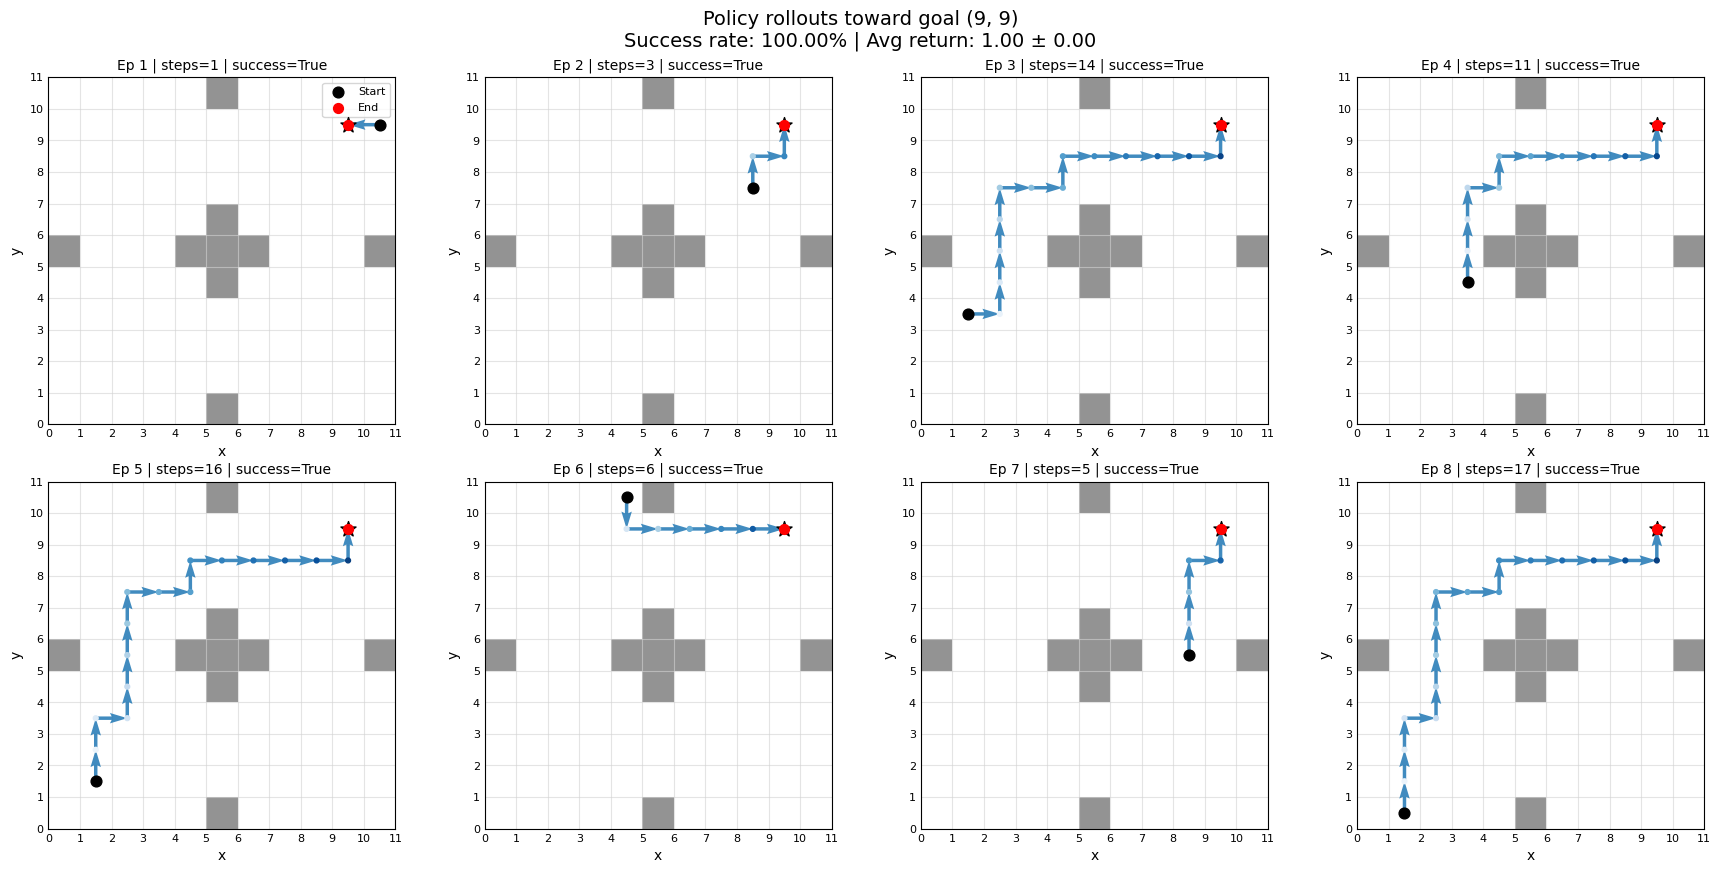

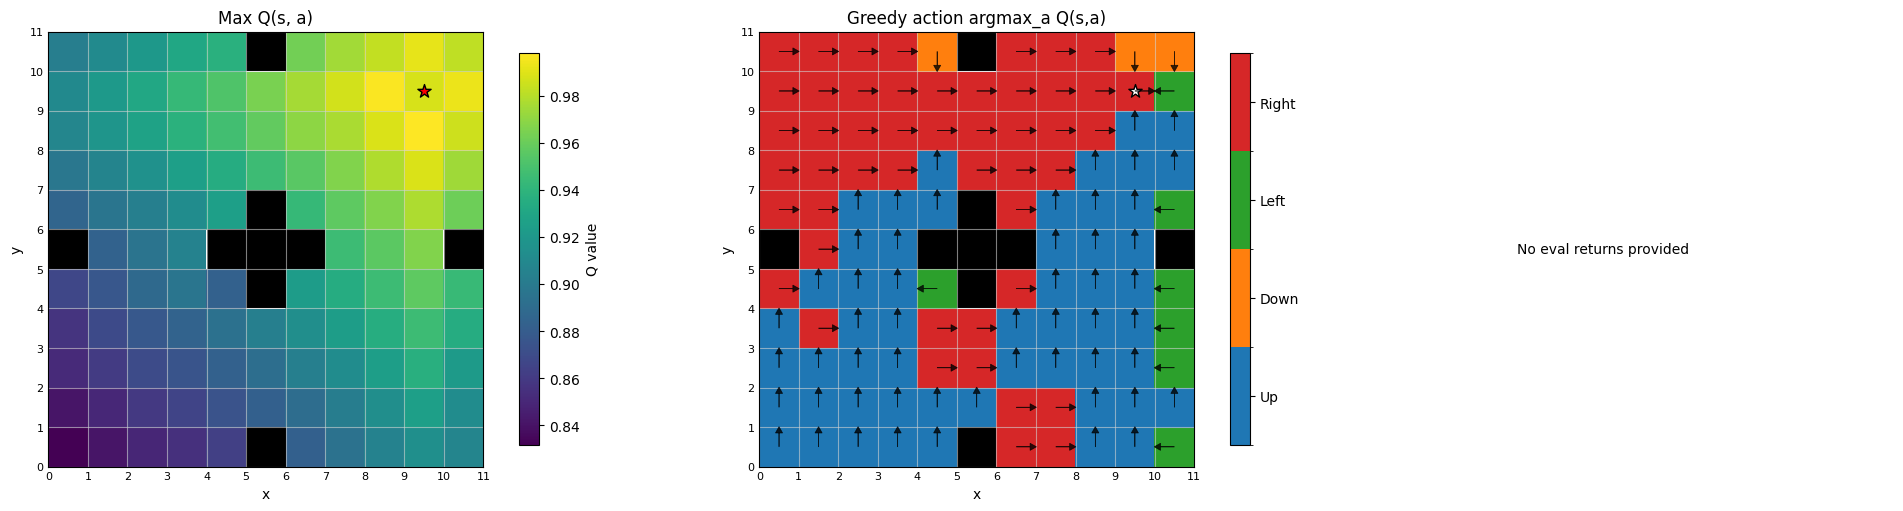


Goal embedding cosine similarity matrix:
     (9, 9)
  (9, 9)      1.000

----- seed=42, goal=(1, 1) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   5000 | eps=0.905 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   6000 | eps=0.886 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.073 | SigReg loss=0.996 | Loss=0.429
[DQN-factorised] step=   7000 | eps=0.867 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.006 | SigReg loss=

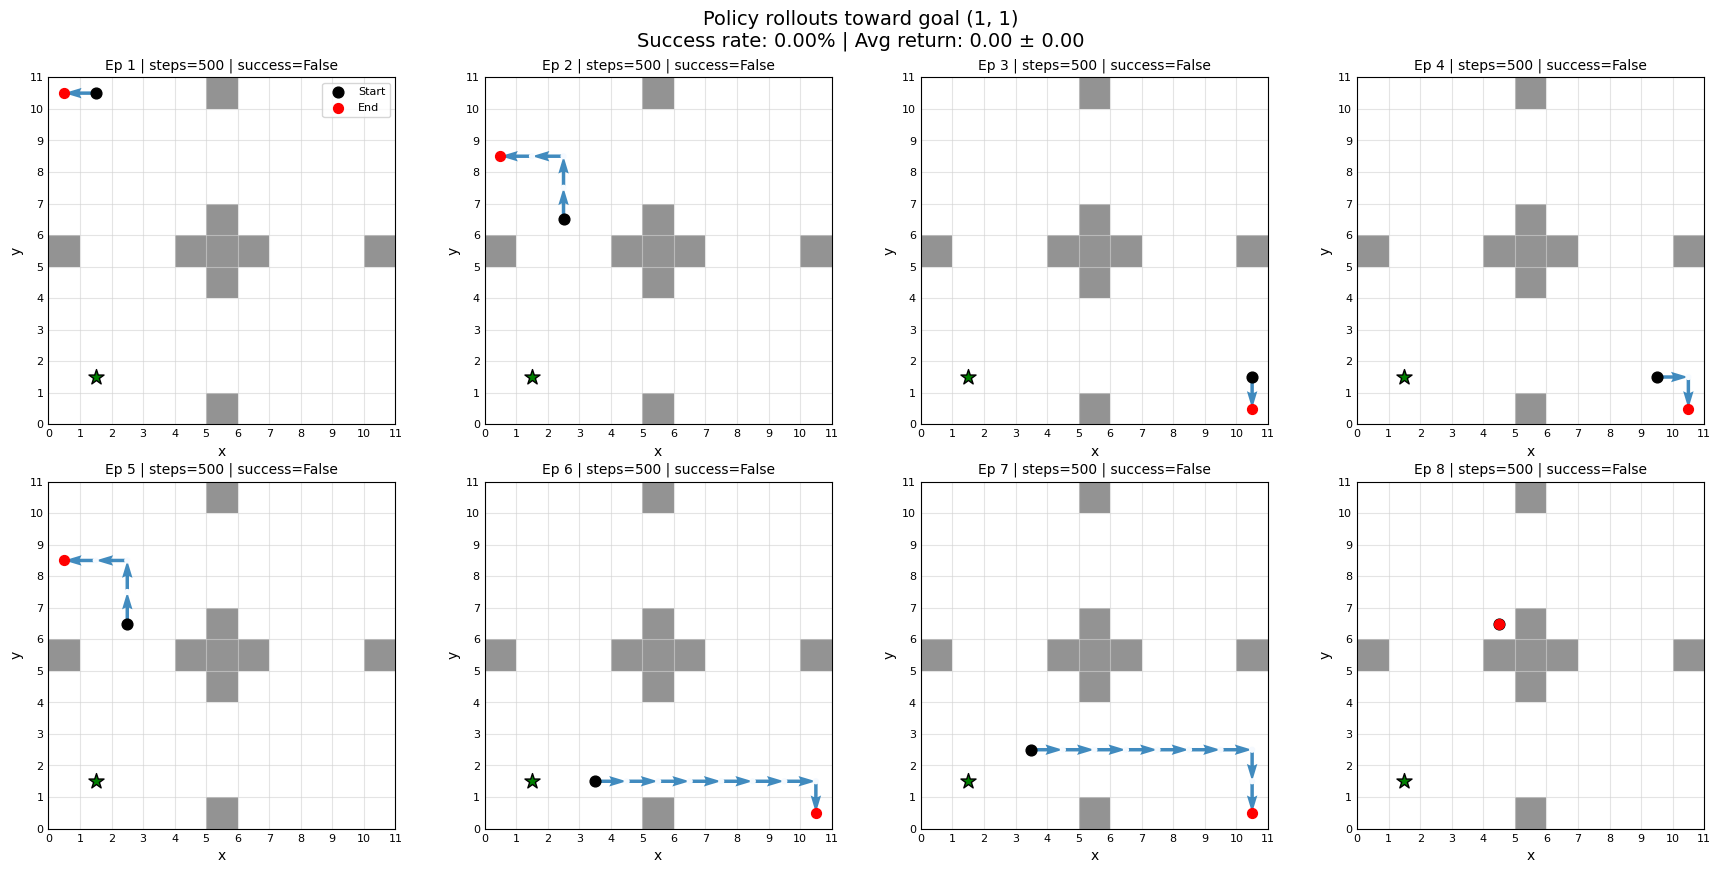

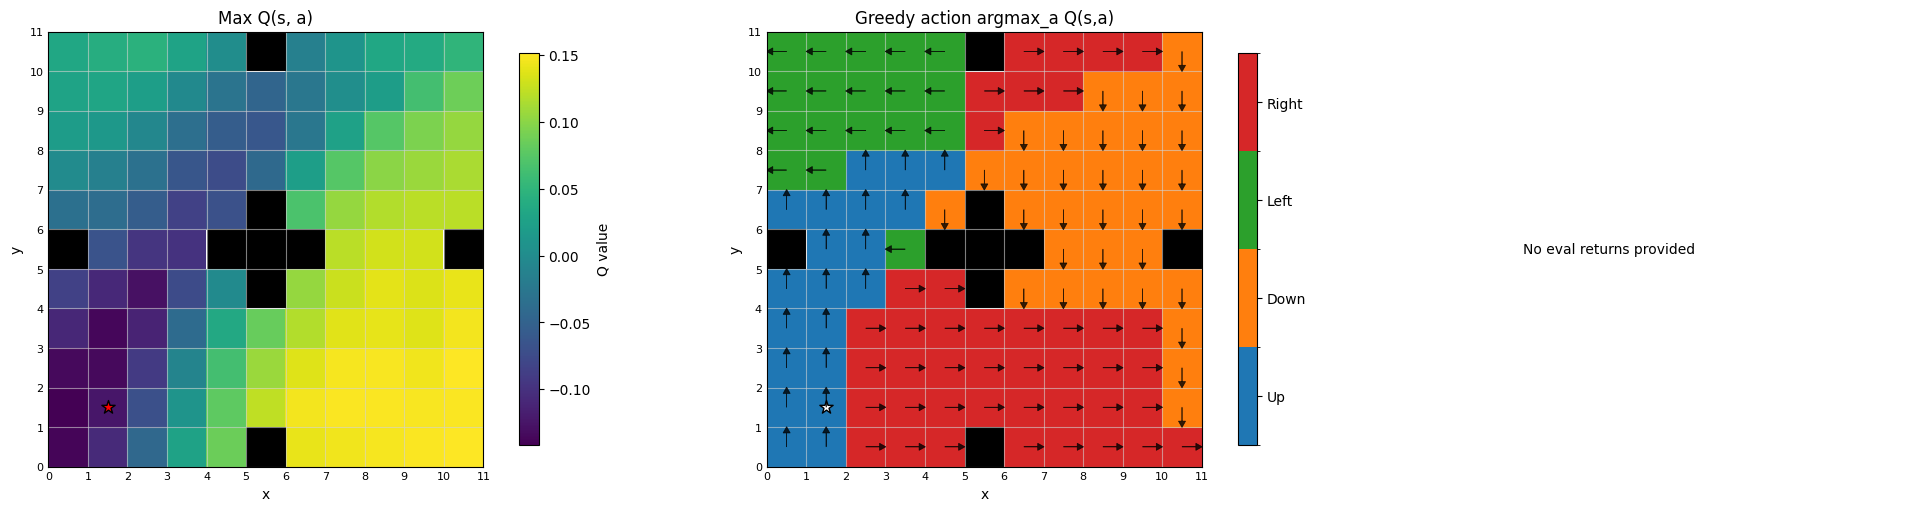


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)
  (9, 9)      1.000     -0.000
  (1, 1)     -0.000      1.000

Off-diagonal mean similarity: -0.000
Off-diagonal min similarity: -0.000
Off-diagonal max similarity: -0.000

----- seed=42, goal=(4, 4) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   5000 | eps=0.905 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   6000 | eps=0.886 | eval_return=0.250 | eval_len=375.2

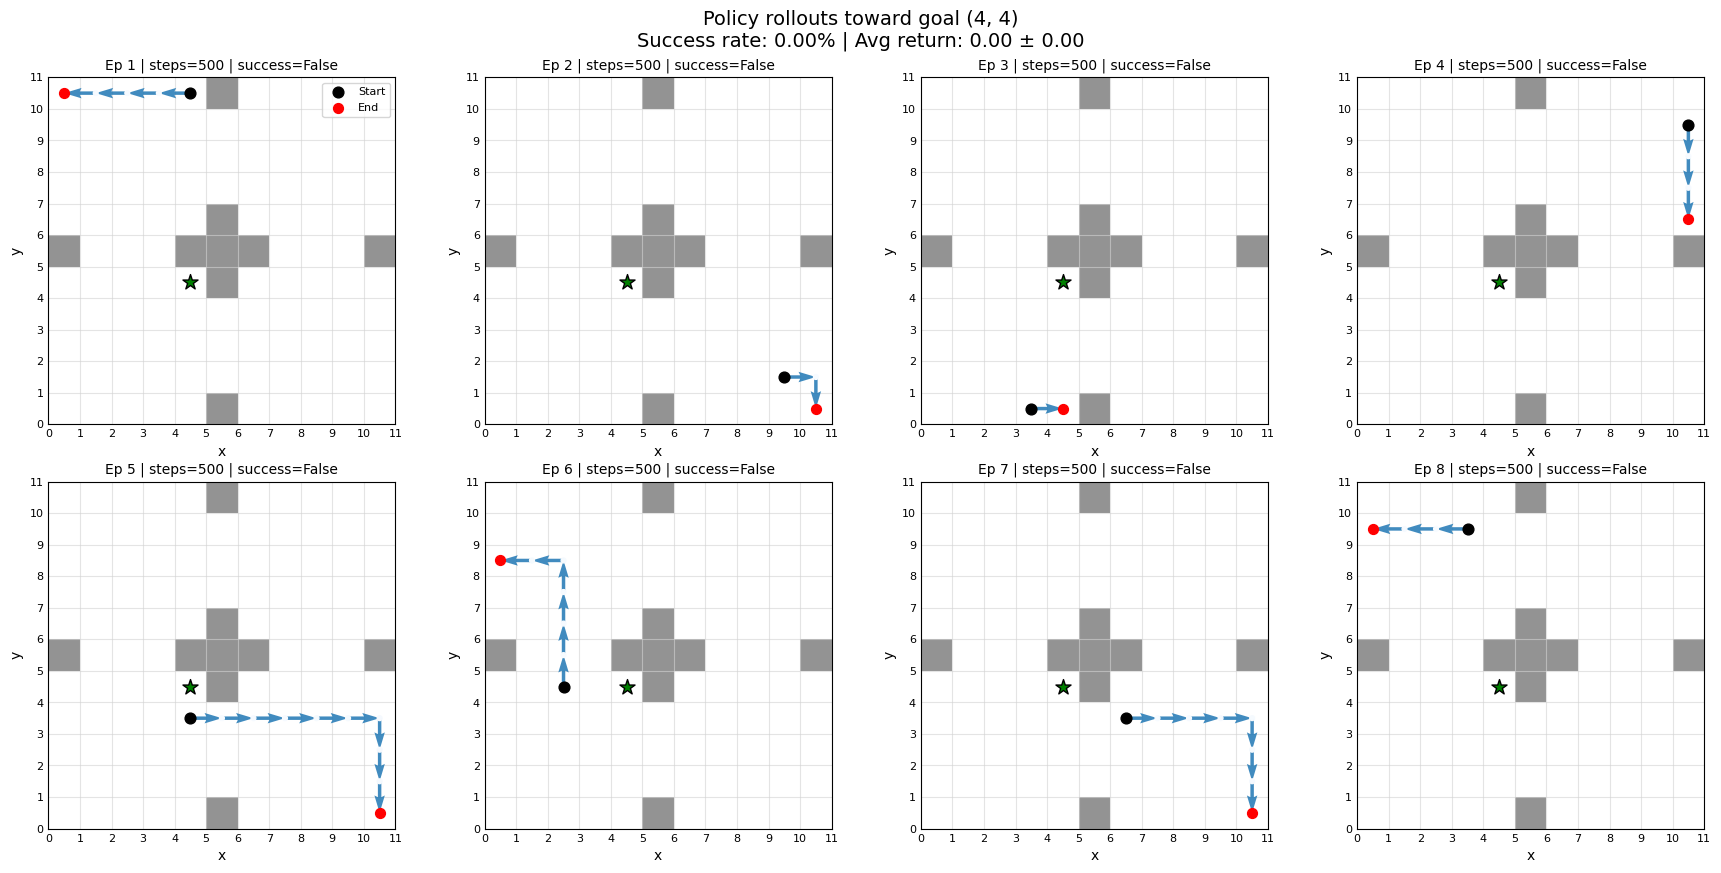

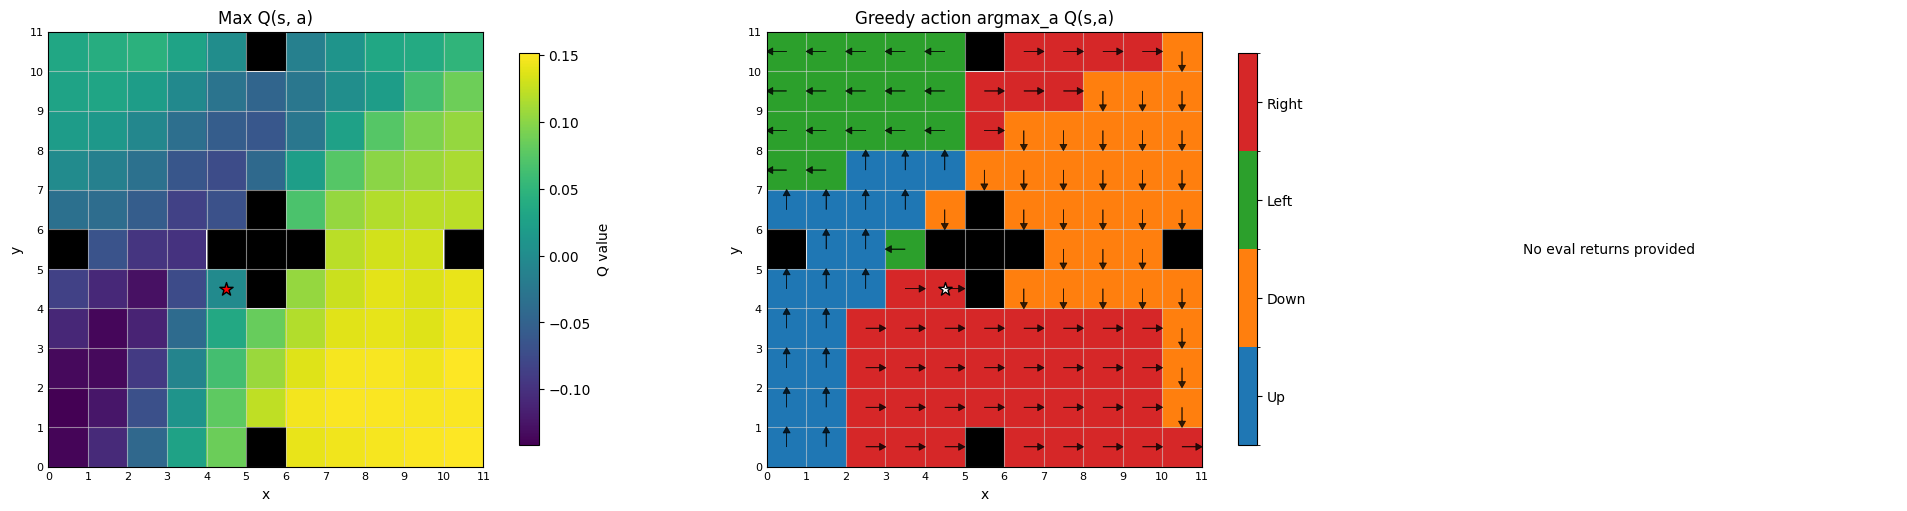


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (4, 4)
  (9, 9)      1.000     -0.000      0.000
  (1, 1)     -0.000      1.000      1.000
  (4, 4)      0.000      1.000      1.000

Off-diagonal mean similarity: 0.333
Off-diagonal min similarity: -0.000
Off-diagonal max similarity: 1.000

----- seed=42, goal=(7, 7) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   5000 | eps=0.905 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-

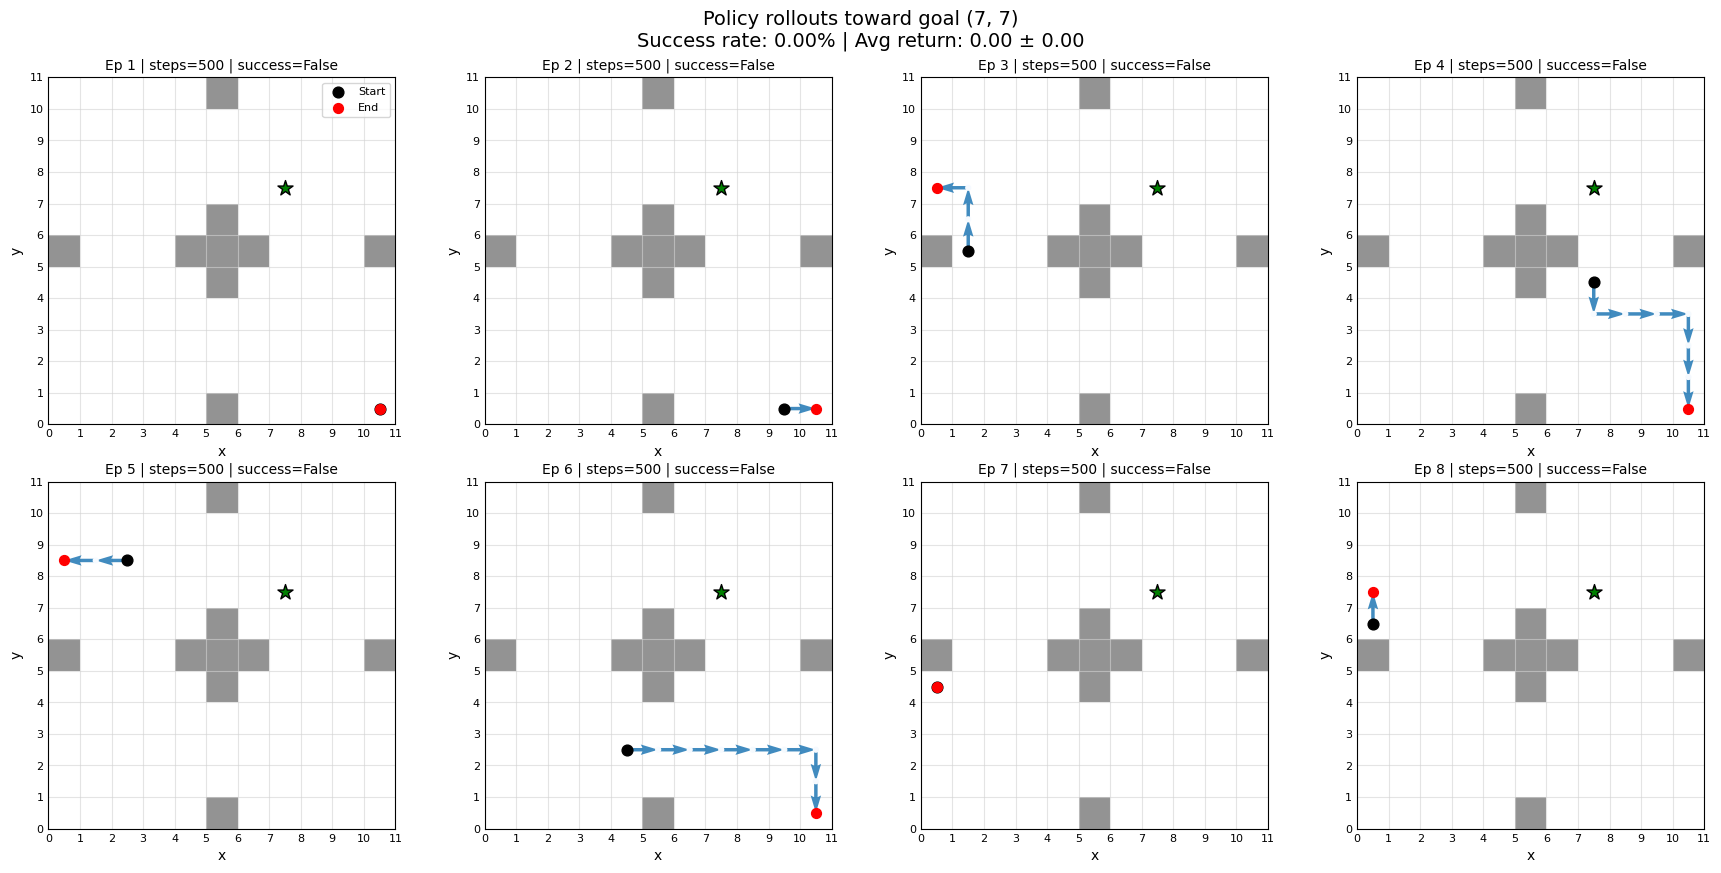

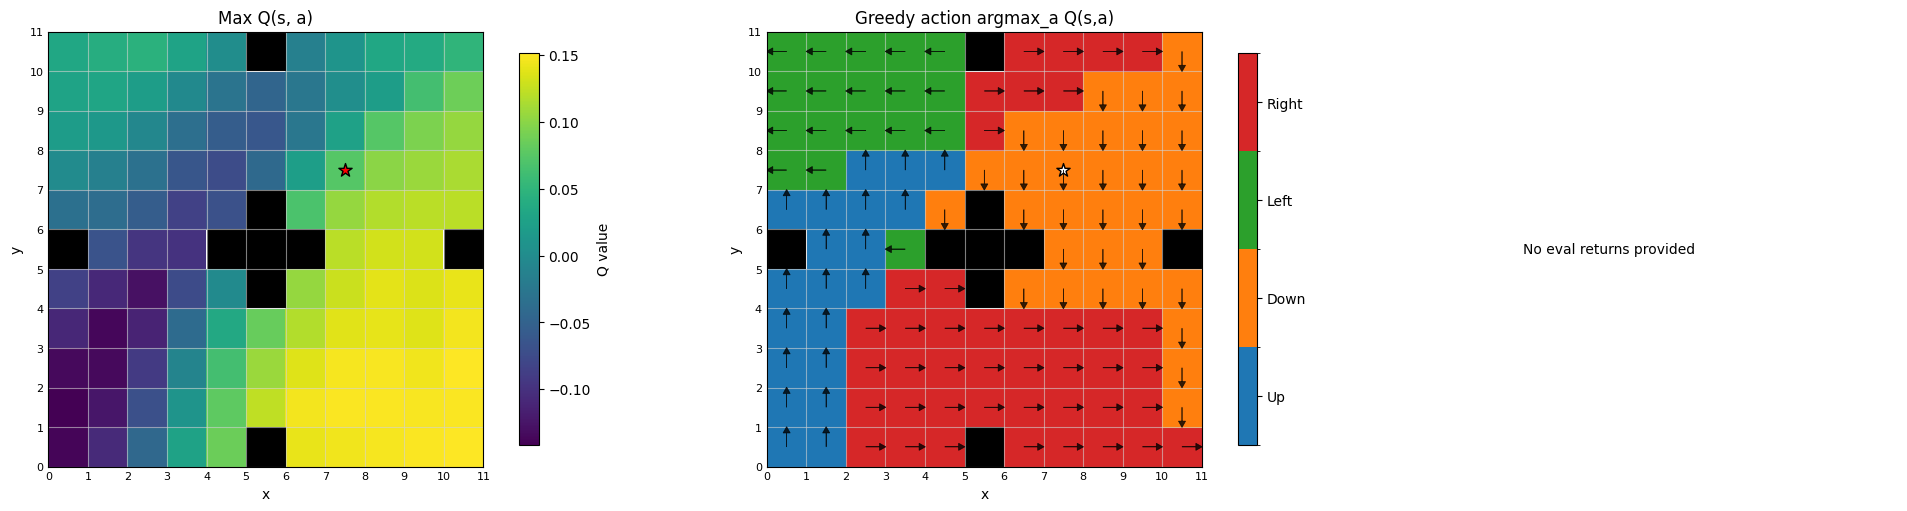


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (4, 4)     (7, 7)
  (9, 9)      1.000     -0.000      0.000      0.000
  (1, 1)     -0.000      1.000      1.000      1.000
  (4, 4)      0.000      1.000      1.000      1.000
  (7, 7)      0.000      1.000      1.000      1.000

Off-diagonal mean similarity: 0.500
Off-diagonal min similarity: -0.000
Off-diagonal max similarity: 1.000

----- seed=42, goal=(2, 8) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.250 | eval_len=375.6| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000
[DQN-factorised] step=   5000 | eps=0.

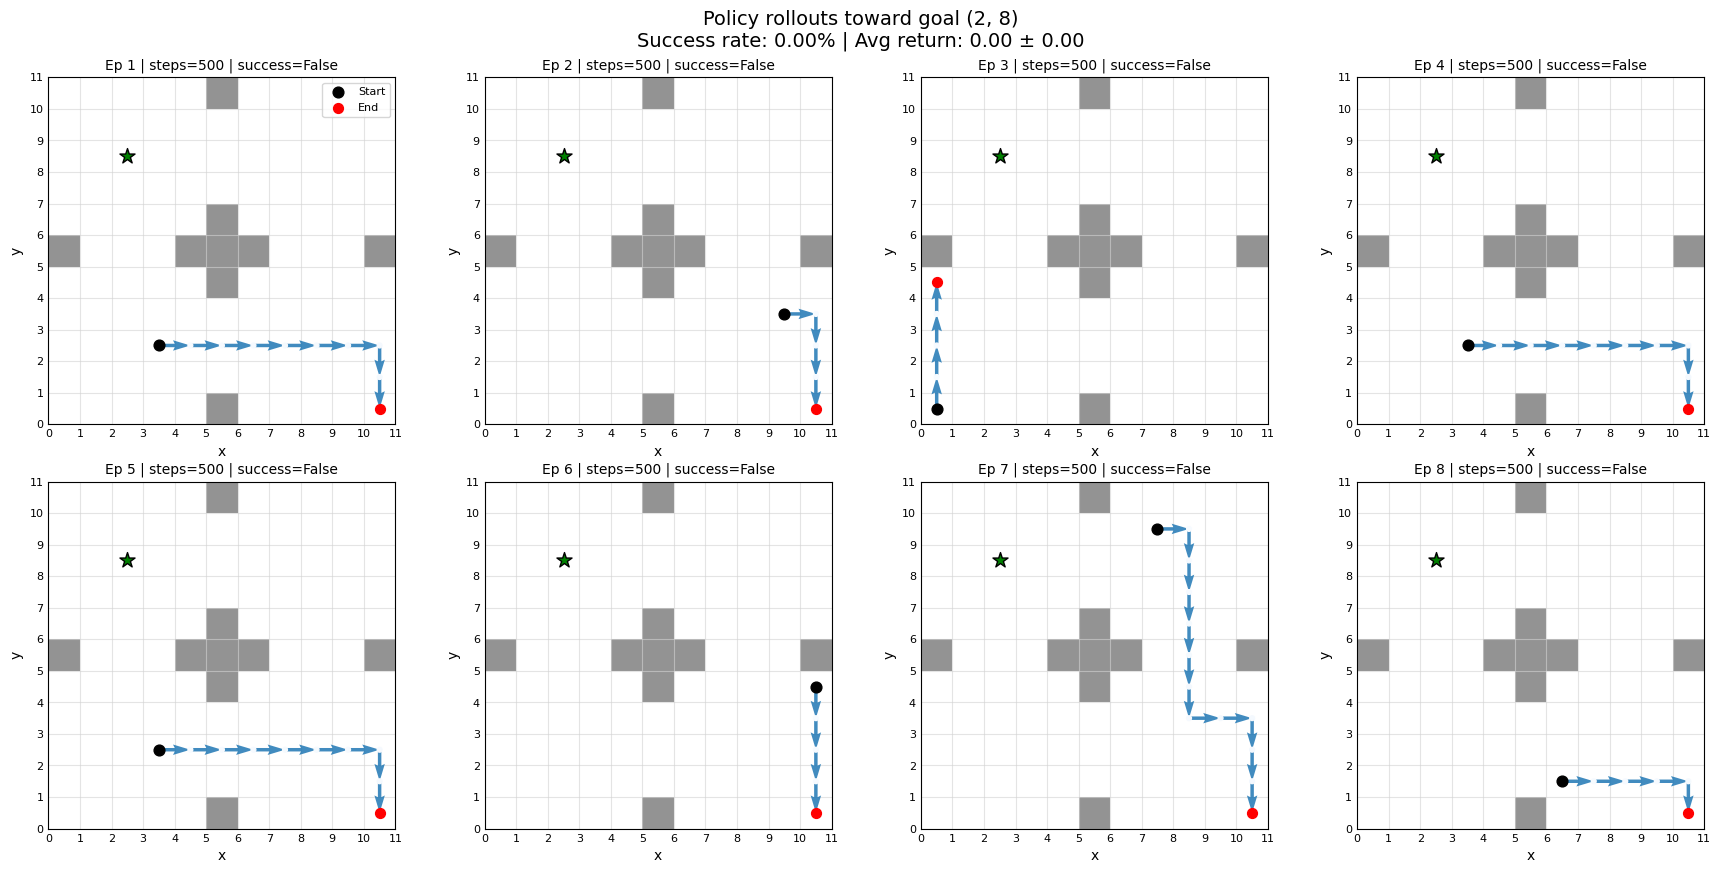

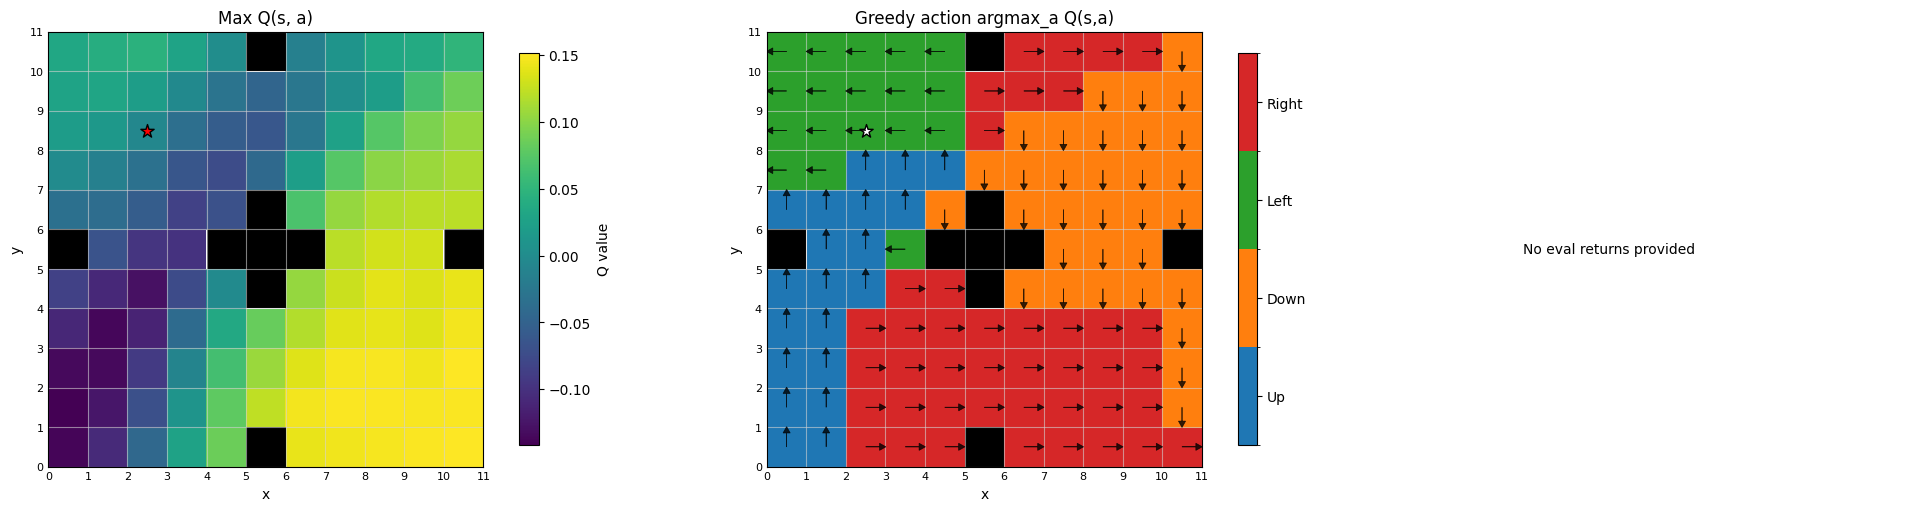


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (4, 4)     (7, 7)     (2, 8)
  (9, 9)      1.000     -0.000      0.000      0.000      0.000
  (1, 1)     -0.000      1.000      1.000      1.000      1.000
  (4, 4)      0.000      1.000      1.000      1.000      1.000
  (7, 7)      0.000      1.000      1.000      1.000      1.000
  (2, 8)      0.000      1.000      1.000      1.000      1.000

Off-diagonal mean similarity: 0.600
Off-diagonal min similarity: -0.000
Off-diagonal max similarity: 1.000


In [6]:
SEEDS = [42]
GOALS = [(9, 9), (1, 1), (4, 4), (7, 7), (2, 8)]

overall_results = {
    goal: {
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
    }
    for goal in GOALS
}

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")
    set_seed(seed)  # your helper

    # Create env to get obs_dim, num_actions once
    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    # One network per seed, reused across goals
    q_net = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    q_target = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)
    q_target.load_state_dict(q_net.state_dict())
    for p in q_target.parameters():
        p.requires_grad_(False)

    # base_goal_encoder_state = deepcopy(q_net.goal_encoder.state_dict())
    # base_obs_last_layer_state = deepcopy(q_net.obs_encoder[-1].state_dict())

    # Per-seed task embedding memory (for repulsion)
    seed_task_embedding_memory = []
    seen_goal_labels = []

    for goal_idx, goal in enumerate(GOALS):
        print(f"\n----- seed={seed}, goal={goal} -----\n")

        # Resync target to current q_net before training on this goal
        q_target.load_state_dict(q_net.state_dict())
        for p in q_target.parameters():
            p.requires_grad_(False)

        # q_net.goal_encoder.load_state_dict(base_goal_encoder_state)
        # q_target.goal_encoder.load_state_dict(base_goal_encoder_state)

        # q_net.obs_encoder[-1].load_state_dict(base_obs_last_layer_state)
        # q_target.obs_encoder[-1].load_state_dict(base_obs_last_layer_state)

        # Decide which params to train (transfer vs. full)
        if goal_idx == 0:
            # First goal: train full network
            for p in q_net.parameters():
                p.requires_grad_(True)
            trainable_params = None  # let dqn_train create its usual optimizer
            regulariser = None
        else:
            # Subsequent goals: reuse phi, train only psi (and optionally last phi layer)
            for p in q_net.sa_encoder.parameters():
                p.requires_grad_(False)
            for p in q_net.goal_encoder.parameters():
                p.requires_grad_(True)

            # If you want psi + last phi layer instead of only psi:
            # last_layer = list(q_net.sa_encoder.children())[-1]
            # for p in last_layer.parameters():
            #     p.requires_grad_(True)

            trainable_params = [p for p in q_net.parameters() if p.requires_grad]
            regulariser = "repulsion"  # or None if you don’t want repulsion here

        # Train on this goal, reusing q_net weights from previous goals
        q_net, q_target, eval_returns, eval_returns_time, min_steps, min_time, task_embedding = dqn_train(
            q_network=q_net,
            q_target_network=q_target,
            env=make_env(goal=goal),
            goal=goal,
            device=DEVICE,
            embedding_memory=seed_task_embedding_memory,  # previous task embeddings in this seed
            regulariser=regulariser,
            reg_alpha=1,          # your choice 
            params=trainable_params # None for full training, list for transfer mode
        )
        visualise_q_table(goal, q_net)
        seed_task_embedding_memory.append(task_embedding)
        seen_goal_labels.append(str(goal))
        print_goal_embedding_similarity(seed_task_embedding_memory, goal_labels=seen_goal_labels)

        overall_results[goal]["eval_returns"].append(eval_returns)
        overall_results[goal]["eval_returns_time"].append(eval_returns_time)
        overall_results[goal]["min_steps"].append(min_steps)
        overall_results[goal]["min_time"].append(min_time)
        overall_results[goal]["task_embeddings"].append(task_embedding)

### Plotting the curves


==== Aggregated results for goal (9, 9) ====
Good-policy step (mean±std): 20000.0 ± 0.0
Good-policy time (mean±std): 60.03s ± 0.00s


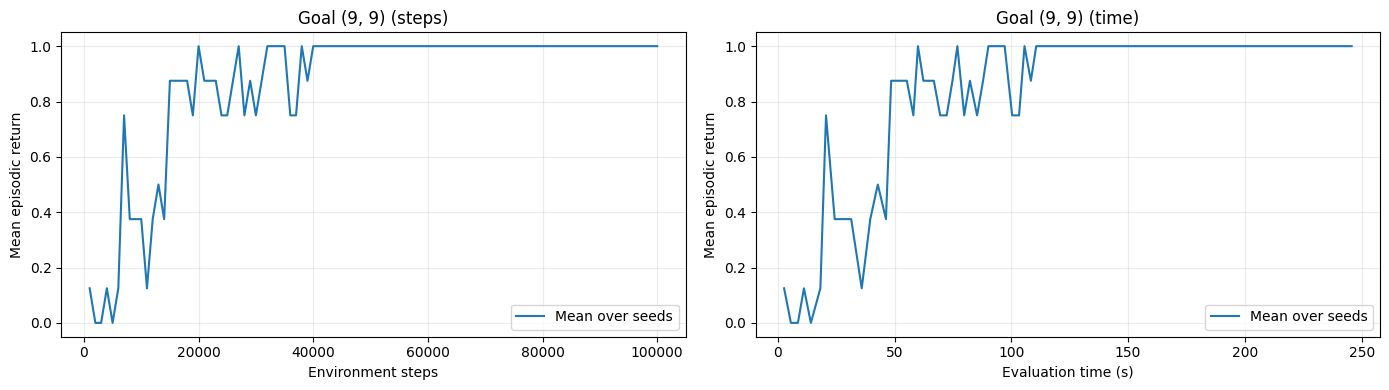


==== Aggregated results for goal (1, 1) ====
Good-policy step: None
Good-policy time: None


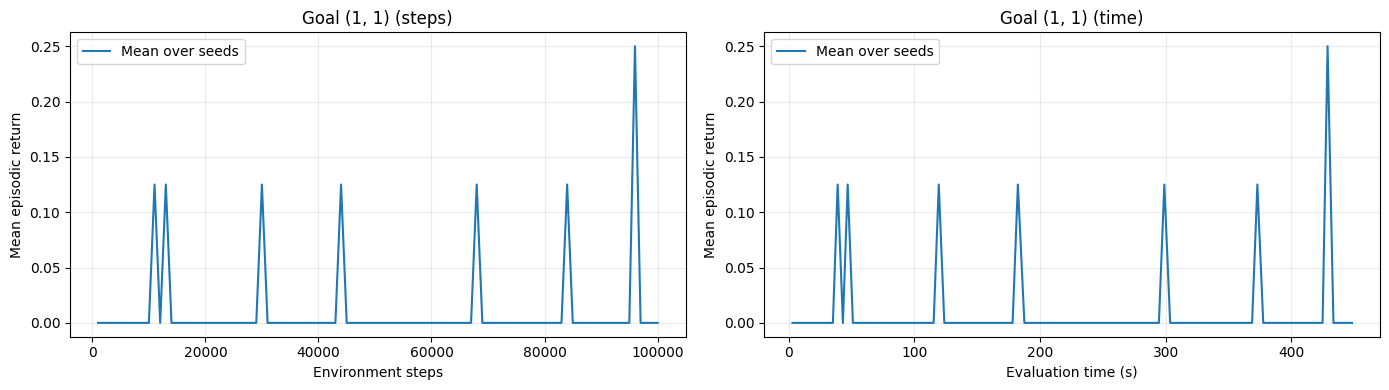


==== Aggregated results for goal (4, 4) ====
Good-policy step: None
Good-policy time: None


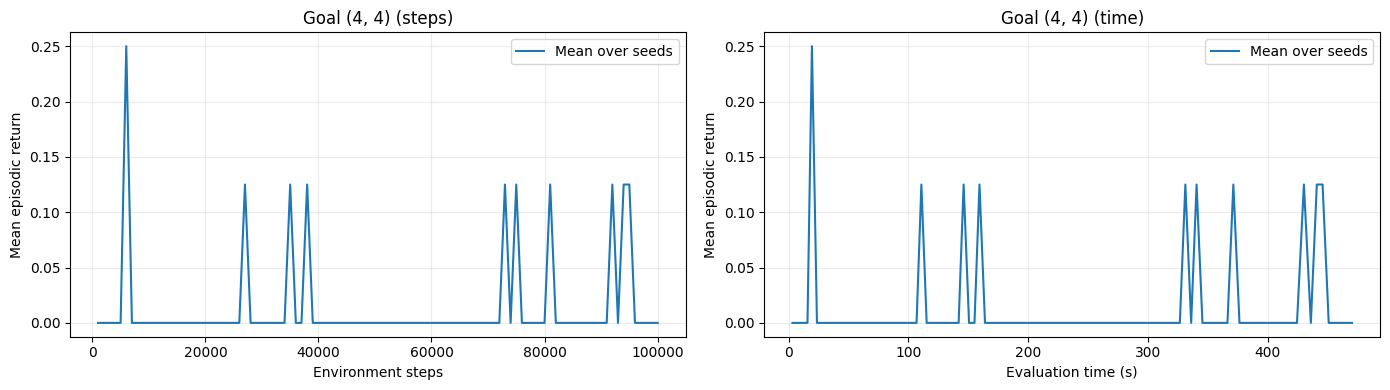


==== Aggregated results for goal (7, 7) ====
Good-policy step: None
Good-policy time: None


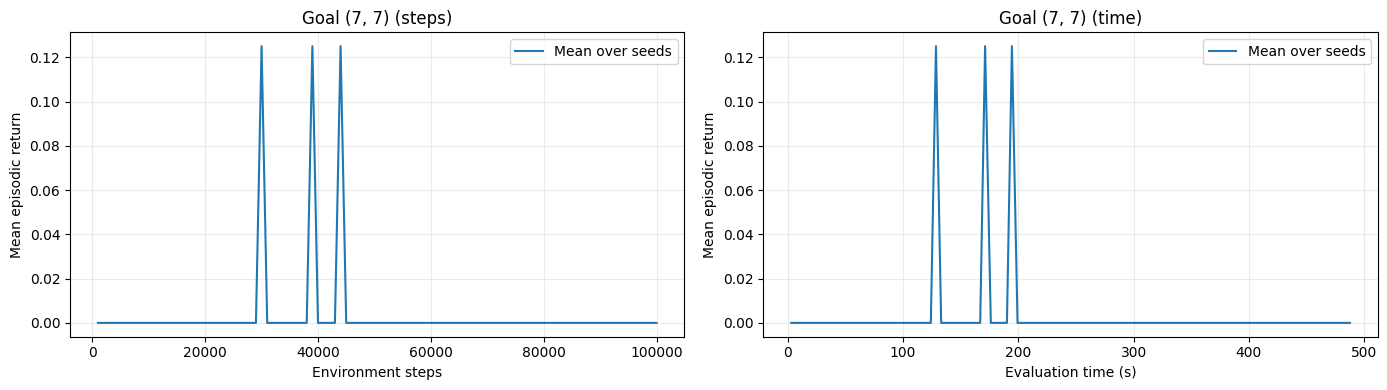


==== Aggregated results for goal (2, 8) ====
Good-policy step: None
Good-policy time: None


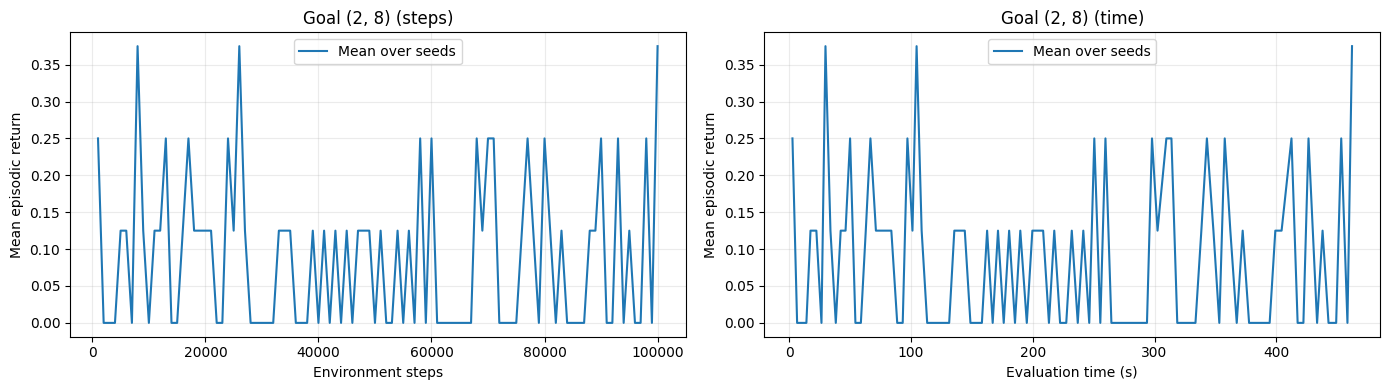

In [7]:
def aggregate_curves(curves):
    curves = [c for c in curves if c is not None and len(c) > 0]
    if len(curves) == 0:
        return None, None, None

    x_grid = np.array([x for x, _ in curves[0]], dtype=np.float32)
    ys_interp = []
    for curve in curves:
        xs = np.array([x for x, _ in curve], dtype=np.float32)
        ys = np.array([y for _, y in curve], dtype=np.float32)
        ys_interp.append(np.interp(x_grid, xs, ys))
    ys_interp = np.stack(ys_interp, axis=0)

    mean_y = ys_interp.mean(axis=0)
    std_y = ys_interp.std(axis=0)
    return x_grid, mean_y, std_y

for goal in GOALS:
    goal_res = overall_results[goal]

    x_steps, mean_ret_steps, std_ret_steps = aggregate_curves(goal_res["eval_returns"])
    x_time, mean_ret_time, std_ret_time = aggregate_curves(goal_res["eval_returns_time"])

    min_steps_list = [s for s in goal_res["min_steps"] if s is not None]
    min_time_list = [t for t in goal_res["min_time"] if t is not None]

    print(f"\n==== Aggregated results for goal {goal} ====")
    if len(min_steps_list) > 0:
        print(f"Good-policy step (mean±std): {np.mean(min_steps_list):.1f} ± {np.std(min_steps_list):.1f}")
    else:
        print("Good-policy step: None")

    if len(min_time_list) > 0:
        print(f"Good-policy time (mean±std): {np.mean(min_time_list):.2f}s ± {np.std(min_time_list):.2f}s")
    else:
        print("Good-policy time: None")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: steps plot
    if x_steps is not None:
        axes[0].plot(x_steps, mean_ret_steps, label="Mean over seeds")
        axes[0].fill_between(
            x_steps,
            mean_ret_steps - std_ret_steps,
            mean_ret_steps + std_ret_steps,
            alpha=0.25,
        )
        axes[0].set_xlabel("Environment steps")
        axes[0].set_ylabel("Mean episodic return")
        axes[0].set_title(f"Goal {goal} (steps)")
        axes[0].grid(alpha=0.25)
        axes[0].legend()
    else:
        axes[0].set_title(f"Goal {goal} (steps)")
        axes[0].text(0.5, 0.5, "No step data", ha="center", va="center")
        axes[0].set_axis_off()

    # Right: time plot
    if x_time is not None:
        axes[1].plot(x_time, mean_ret_time, label="Mean over seeds")
        axes[1].fill_between(
            x_time,
            mean_ret_time - std_ret_time,
            mean_ret_time + std_ret_time,
            alpha=0.25,
        )
        axes[1].set_xlabel("Evaluation time (s)")
        axes[1].set_ylabel("Mean episodic return")
        axes[1].set_title(f"Goal {goal} (time)")
        axes[1].grid(alpha=0.25)
        axes[1].legend()
    else:
        axes[1].set_title(f"Goal {goal} (time)")
        axes[1].text(0.5, 0.5, "No time data", ha="center", va="center")
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()

## Visualisations of q table

### Plot the output embeddings of the network

In [8]:

def visualise_embeddings(goal, q_network):
    eval_env_first = make_env(goal=goal)   
    base_goal = np.array(goal, dtype=np.float32)
    base_goal_t = torch.tensor(base_goal, dtype=torch.float32, device=DEVICE).unsqueeze(0)

    states_base, coords_base = collect_valid_states_fourrooms(eval_env_first)
    obs_base_t = torch.tensor(states_base, dtype=torch.float32, device=DEVICE)

    q_network.eval()
    with torch.no_grad():
        phi_s_base = q_network.encode_state(obs_base_t).cpu().numpy()          # [N, D]
        psi_z_base = q_network.encode_goal(base_goal_t).cpu().numpy()          # [1, D]
        phi_sa_base = q_network.encode_state_action(obs_base_t).cpu().numpy()  # [N, A, D]

    N_base, A_base, D_base = phi_sa_base.shape
    phi_sa_base_flat = phi_sa_base.reshape(N_base * A_base, D_base)

    print("states_base:", states_base.shape)
    print("coords_base:", coords_base.shape)
    print("phi(s) base:", phi_s_base.shape)
    print("phi(s,a) base:", phi_sa_base.shape)
    print("psi(z) base:", psi_z_base.shape)

    # Convert to torch
    phisa_t = torch.tensor(phi_sa_base_flat, dtype=torch.float32)
    psi_t   = torch.tensor(psi_z_base.squeeze(0), dtype=torch.float32)  # [D]

    # 1) Norm statistics
    norms = phisa_t.norm(dim=-1)   # [N*A]
    print(f"phi(s,a) norms: mean={norms.mean().item():.4f}, std={norms.std().item():.4f}")

    # 2) Effective rank (via singular values)
    # Center first to remove mean
    phisa_centered = phisa_t - phisa_t.mean(dim=0, keepdim=True)
    U, S, Vh = torch.linalg.svd(phisa_centered, full_matrices=False)
    S_np = S.cpu().numpy()
    explained = (S_np ** 2) / (S_np ** 2).sum()
    cumulative = explained.cumsum()

    print(f"top 5 singular values:", S_np[:5])
    print(f"cumulative variance (first 5 dims):", cumulative[:5])

    # Optional: plot variance spectrum
    plt.figure(figsize=(6, 4))
    plt.plot(cumulative, marker="o")
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative variance explained")
    plt.title(f"Variance spectrum of phi(s,a) [{goal}]")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3) Cosine similarities between phi(s,a) and psi(z)
    psi_unit = psi_t / (psi_t.norm() + 1e-8)              # ensure unit norm
    phisa_unit = phisa_t / (phisa_t.norm(dim=-1, keepdim=True) + 1e-8)

    cos = (phisa_unit @ psi_unit)                        # [N*A]
    cos_np = cos.cpu().numpy()

    print(f"cos(phi(s,a), psi): mean={cos_np.mean():.4f}, std={cos_np.std():.4f}")
    plt.figure(figsize=(6, 4))
    plt.hist(cos_np, bins=40, alpha=0.7)
    plt.xlabel("cos(phi(s,a), psi(z))")
    plt.ylabel("count")
    plt.title(f"Cosine histo phi(s,a) vs psi(z) [{goal}]")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

for goal in GOALS:
    print(f"\nAnalyzing embeddings for goal {goal}...\n")
    visualise_embeddings(goal, q_net)   



Analyzing embeddings for goal (9, 9)...



AttributeError: 'FactorisedDQN_QNetwork' object has no attribute 'encode_state'

## ABA test to check whether the old policy gets affected